In [1]:
import cv2
import matplotlib.pyplot as plt
import os


from utils import *
from darknet import Darknet

In [2]:
# Set the location and name of the cfg file
cfg_file = '../data/cfg/crop_weed.cfg'

# Set the location and name of the pre-trained weights file
# add weights file name here if you have your own
weight_file = '../data/weights/' + 'crop_weed_detection.weights'

# Set the location and name of the object classes file
namesfile = '../data/names/obj.names'

# Load the network architecture
m = Darknet(cfg_file)

# Load the pre-trained weights
m.load_weights(weight_file)

# Load the COCO object classes
class_names = load_class_names(namesfile)

# Taking a Look at The Neural Network

Now that the neural network has been setup, we can see what it looks like. We can print the network using the `.print_network()` function.


In [3]:
# Print the neural network used in YOLOv3
m.print_network()

layer     filters    size              input                output
    0 conv     32  3 x 3 / 1   512 x 512 x   3   ->   512 x 512 x  32
    1 conv     64  3 x 3 / 2   512 x 512 x  32   ->   256 x 256 x  64
    2 conv     32  1 x 1 / 1   256 x 256 x  64   ->   256 x 256 x  32
    3 conv     64  3 x 3 / 1   256 x 256 x  32   ->   256 x 256 x  64
    4 shortcut 1
    5 conv    128  3 x 3 / 2   256 x 256 x  64   ->   128 x 128 x 128
    6 conv     64  1 x 1 / 1   128 x 128 x 128   ->   128 x 128 x  64
    7 conv    128  3 x 3 / 1   128 x 128 x  64   ->   128 x 128 x 128
    8 shortcut 5
    9 conv     64  1 x 1 / 1   128 x 128 x 128   ->   128 x 128 x  64
   10 conv    128  3 x 3 / 1   128 x 128 x  64   ->   128 x 128 x 128
   11 shortcut 8
   12 conv    256  3 x 3 / 2   128 x 128 x 128   ->    64 x  64 x 256
   13 conv    128  1 x 1 / 1    64 x  64 x 256   ->    64 x  64 x 128
   14 conv    256  3 x 3 / 1    64 x  64 x 128   ->    64 x  64 x 256
   15 shortcut 12
   16 conv    128  1 x 1

In [4]:
# plot images in 'performing_detection\data\images' folder
img_folder = '../data/images/'
img_files = os.listdir(img_folder)
img_files = [img_folder + img_file for img_file in img_files]

# Object Detection


In [5]:
def detect_and_plot_objects(img_path, model, class_names, iou_threshold=0.4, nms_threshold=0.6):
    # Load an image
    img = cv2.imread(img_path)
    original_image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize the image to the input width and height of the first layer of the network.
    resized_image = cv2.resize(original_image, (model.width, model.height))

    # Detect objects in the image
    boxes = detect_objects(model, resized_image, iou_threshold, nms_threshold)

    # Print the objects found and the confidence level
    print_objects(boxes, class_names)

    # Plot the image with bounding boxes and corresponding object class labels
    plot_boxes(original_image, boxes, class_names, plot_labels=True)
    plt.show()

# Use detection function with any image




It took 1.754 seconds to detect the objects in the image.

Number of Objects Detected: 1 

Objects Found and Confidence Level:

1. weed: 0.999898


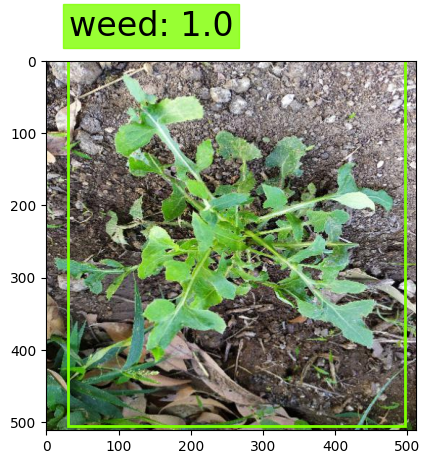

In [7]:
img_path = img_files[-1]

detect_and_plot_objects(img_path, m, class_names)